In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import os
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from omegaconf import OmegaConf

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from brokenaxes import brokenaxes
# from curve_utils import plot_one_image_curve

In [20]:

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}
info_dict = [
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': True},

        {'freeze_encoder': 0, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},

            ]

## Prelim

In [21]:
project_dir = '/gpfs01/berens/user/inwabufo/leverage/leverage-data'
from omegaconf import OmegaConf

CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
metadata_dir = os.path.join(project_dir, 'metadata')
log_dir = 'log_dir'
hostname_ = 'CIN'
dataset_name = 'areds_new'
split_id = 11042026

config_file = '/gpfs01/berens/user/inwabufo/.secrets.yaml'
cfg = OmegaConf.load(config_file)
stylef = cfg['stylef'][hostname_]
CHKPT_DIR = chkpt_dir = os.path.join(project_dir, 'chkpt_dir', 'npj_areds_curves')
RESULTS_DIR = os.path.join(project_dir, 'results')
project_dir = cfg['DATASETS'][hostname_][dataset_name]
stylef = cfg['stylef'][hostname_]
img_dir = f"{project_dir}"
img_dir

'/gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula'

In [22]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [23]:
metadata_dir

'/gpfs01/berens/user/inwabufo/leverage/leverage-data/metadata'

In [24]:
metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(metadata_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test.head()

/tmp/ipykernel_738947/3305201377.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0


In [25]:
test[test['image_path']=='58462/58462_04_F2_RE_RS.jpg']

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
8053,4937,4937_right,4937_right_RS_04,4,right,F2,RS,58462_04_F2_RE_RS.jpg,58462/58462_04_F2_RE_RS.jpg,6.0,...,4.0,N,N,NaN,NaN,70.4,4937_right,4937_right_4,8,1


In [26]:
test['patient_id'] = test['patient_id'].astype(str)

## Nested data

In [27]:
import matplotlib.image as mpimg
from curve_utils import get_all_curves, pick_same_index_across_lists
import random
def plot_one_image_curve(or_df, test, freeze_encoder = 1, train_size = 500, 
                         num_images = None, has_event = True, CHKPT_DIR = '', 
                         to_plot_row_index = None, patient_id = None):

    """
    num_images: determines how many images per patient would be shown
    
    """
    dfl = or_df[(or_df['freeze_encoder'] == freeze_encoder) & (or_df['survival_head'] == 'mlp') & (or_df['train_size'] == train_size)]
    dfl_ssl = dfl.groupby(['weights_path']).agg(list)

    dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
    model_list = sorted(list(dfl_ssl['model'].unique()))
    # print('model list',model_list)
    dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)) )

    dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)
    dfl_ssl['best_result'].head()

    test['converter'] = test['diagnosis_amd_grade'].apply(lambda x: x in [10, 11, 12])
    test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
    test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
    test_grp['n_img'].value_counts()

    test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
    test_grp['has_event'].value_counts()

    # print(test_grp.columns)

    sample_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == has_event)].reset_index(drop = False)
    # print('sample', sample_[['patient_id', 'visit_number', 'converter', 'has_event', 'diagnosis_amd_grade', 'image_path']])
    if patient_id is not None:
        matches = sample_.index[sample_['patient_id'].apply(lambda x: x[0] if isinstance(x, list) else x) == patient_id].tolist()
        if not matches:
            raise ValueError(f"patient_id {patient_id} not found in filtered sample_ (freeze_encoder={freeze_encoder}, train_size={train_size}, has_event={has_event})")
        to_plot_row_index = matches[0]
    elif to_plot_row_index is None:
        to_plot_row_index = random.randint(0, (len(sample_) - 1))

    # if to_plot_row_index is None:
    #     to_plot_row_index = random.randint(0,(len(sample_)-1))
    # print('to_plot_row_index is', to_plot_row_index)
    
    # selects all the images related to an ID. The row from the dataframe is determined by to_plot_row_index
    all_images_to_plot =  sample_.loc[to_plot_row_index, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number", "converter"]]
    all_images_to_plot['train_size'] = train_size
    # print('all_images_to_plot', all_images_to_plot.shape)
    # print('all_images_to_plot', all_images_to_plot)

    # of ID of a person, determined how many images to plot
    all_images_to_plot = pick_same_index_across_lists(all_images_to_plot, num_images = num_images)

    # print('--------------------------------------')
    # print()
    # print(all_images_to_plot)
    # print('--------------------------------------')
    # print()
    curves_dict ={}

    curves_dict = get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)
    return curves_dict, all_images_to_plot, train_size

def draw_curves(data_to_plot, curves_dict,
                first_conversion_idx=None,
                 marker_panel_idx=None, 
                 save_path=None, stylef=None):
    """
    all_img_to_plot : [images, labels, [img_id]]
                      labels = list of diagnosis_amd_grade per visit
    curves_dict     : {model_name: [curve_visit_0, curve_visit_1, ...]}

    Conversion marker: a single grey downward triangle on the x-axis at the
    conversion year, shown only in the penultimate panel (last pre-conversion visit).
    """
    color_groups = {
        'dino_nako': '#000000',
        'dino_meta': '#05771D',
        'retfound':  '#90A4AE',
        'nako_mae':  '#6A1B9A',
        'simclr_inet_nako': '#D81B60',
        'simclr_nako': '#F3D0DC',
        'scratch': '#1565C0',
        'resnet_imagenet': '#42A5F5',
    }
    new_names = {
        'dino_nako': 'DINOv2 NAKO',
        'dino_meta': 'DINOv2 LVD',
        'retfound': 'RETFound',
        'resnet_imagenet': 'ResNet INet',
        'nako_mae': "MAE NAKO",
        'simclr_nako': 'SimCLR NAKO',
        'simclr_inet_nako': 'SimCLR INet NAKO',
        'scratch': "ResNet Scratch"
    }

    all_img_to_plot = data_to_plot['image_path']
    # print('all_img_to_plot', all_img_to_plot)

    n_images = len(all_img_to_plot)

    # 2 rows: curves on top, images below
    fig = plt.figure(figsize=(n_images * 3, n_images + 2))
    gs = gridspec.GridSpec(
        2, n_images, figure=fig,
        wspace=0.3, hspace=0.15,
        height_ratios=[3, 1]   # top row taller than bottom image row
    )

    y_min = min(min(curve) for curves in curves_dict.values() for curve in curves) - 0.02
    y_max = 1
    x = [1, 2, 3, 4, 5]

    grades = data_to_plot['diagnosis_amd_grade']
    print(grades)
    visit_number = data_to_plot['visit_number']
    visit_number = [int(x/2) for x in visit_number]
    train_size = data_to_plot['train_size'][0]

    marker_x = None

    if any(g in [10, 11, 12] for g in grades):
        if first_conversion_idx is None:
            first_conversion_idx = next(
                (i for i, g in enumerate(grades) if g >= 10), None
            )
            print('first conversion index is', first_conversion_idx)
            if marker_panel_idx is None and first_conversion_idx > 0:
                marker_panel_idx = first_conversion_idx - 2
            marker_x = visit_number[first_conversion_idx] - visit_number[marker_panel_idx]
          
        else:
            marker_x = first_conversion_idx

    print(f'marker x is {marker_x} marker_panel_idx is {marker_panel_idx}')
    

    with plt.style.context(stylef):
        for i, img in enumerate(all_img_to_plot):
            bax = brokenaxes(
                xlims=((-0.1, 0.002), (0.9, max(x) + 0.1)),
                hspace=0.01,
                d=0.001,
                tilt=45,
                subplot_spec=gs[0, i],   # <-- top row only
                fig=fig
            )

            for model, curves in curves_dict.items():
                curve_to_plot = curves[i]
                bax.plot(
                    range(1, len(curve_to_plot) + 1),
                    curve_to_plot,
                    label=new_names[model],
                    color=color_groups[model],
                    linewidth=1.5
                )

            if i == marker_panel_idx and marker_x is not None:
                bax.axs[1].plot(
                    marker_x,
                    0.02,
                    marker='v',
                    markersize=10,
                    color='grey',
                    linestyle='none',
                    clip_on=False,
                    zorder=5
                )

            img_id = all_img_to_plot[0].split('/')[0]
            bax.set_title(f"ID {img_id} tr {train_size} V_no {visit_number[i]} Label {int(grades[i])}", 
            fontsize=10)
            bax.set_ylim(y_min, y_max)
            if i == 0:
                bax.set_ylabel('S(t)', fontsize=10)
            if i == len(all_img_to_plot[0]) // 2:
                bax.set_xlabel('Year', fontsize=10)
            bax.axs[0].set_xticks([])
            bax.axs[1].set_xticks([1, 2, 3, 4, 5, 6, 7])
            for ax in bax.axs:
                ax.tick_params(axis='both', labelsize=10)
                ax.set_yticks([0, 0.5, 1.0])

            if i == len(all_img_to_plot[0]) - 1:
                handles, labels = [], []
                for model in curves_dict:
                    handles.append(plt.Line2D([0], [0],
                                               color=color_groups[model],
                                               linewidth=1.5))
                    labels.append(new_names[model])

                if marker_panel_idx is not None and marker_x is not None:
                    handles.append(plt.Line2D([0], [0],
                                               marker='v', color='w',
                                               markerfacecolor='grey',
                                               markersize=8,
                                               linestyle='none'))
                    labels.append('Conversion')

                leg = bax.legend(
                    handles, labels,
                    loc='lower left',
                    bbox_to_anchor=(1, 0.2),
                    labelspacing=1.5,
                    fontsize=8,
                    handler_map={plt.Line2D: HandlerLine2D(numpoints=3)}
                )
                for line in leg.get_lines():
                    line.set_linewidth(1.5)

            # ── NEW: image row below this panel ────────────────────────────
            ax_img = fig.add_subplot(gs[1, i])
            try:
                img_path = os.path.join(img_dir,f'R_{img}')
                image = mpimg.imread(img_path)
                ax_img.imshow(image)
            except Exception as e:
                print(f"Could not load image {img}: {e}")
            ax_img.axis('off')
            # ─────────────────────────────────────────────────────────────

    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_{img_id}.pdf')
    plt.show()
    
def draw_curves_nested(nested_data, first_conversion_idx=None,
                              marker_panel_idx=None, save_path=None, stylef=None):
    """
    nested_data: {
        pid: {
            image_path: {
                'diagnosis_amd_grade': ...,
                'visit_number': ...,
                'model_curves': {model_name: curve, ...}
            },
            ...
        },
        ...
    }
    """
    for pid, images in nested_data.items():

        image_paths = list(images.keys())

        data_to_plot = {
            'image_path': image_paths,
            'diagnosis_amd_grade': [images[p]['diagnosis_amd_grade'] for p in image_paths],
            'visit_number': [images[p]['visit_number'] for p in image_paths],
            'train_size': [images[p]['train_size'] for p in image_paths],   # <-- added

        }
        # print(data_to_plot)
        # print('image_paths',image_paths)
        # print('image_paths[0]',image_paths[0])

        # Rebuild curves_dict: {model_name: [curve_visit0, curve_visit1, ...]}
        model_names = images[image_paths[0]]['model_curves'].keys()
        curves_dict = {
            model: [images[p]['model_curves'][model] for p in image_paths]
            for model in model_names
        }

        draw_curves(
            data_to_plot,
            curves_dict,
            first_conversion_idx=first_conversion_idx,
            marker_panel_idx=marker_panel_idx,
            save_path=save_path,
            stylef=stylef
        )

In [28]:
goodids = ['3290', '3935']

In [29]:
pid_to_check = '2346'

In [30]:
all_pid = list(set(test['patient_id']))
len(all_pid)

886

In [31]:
no_pid = []

In [32]:
pds_to_check  = ['1234', '1638', '1732', '1858', '2076', '2346', '2923', 
     '2946', '3290', '3538', '3935', '4074', '4937', '5455', '5556', 'G112', 'G153', 
     'G255', 'G554']

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

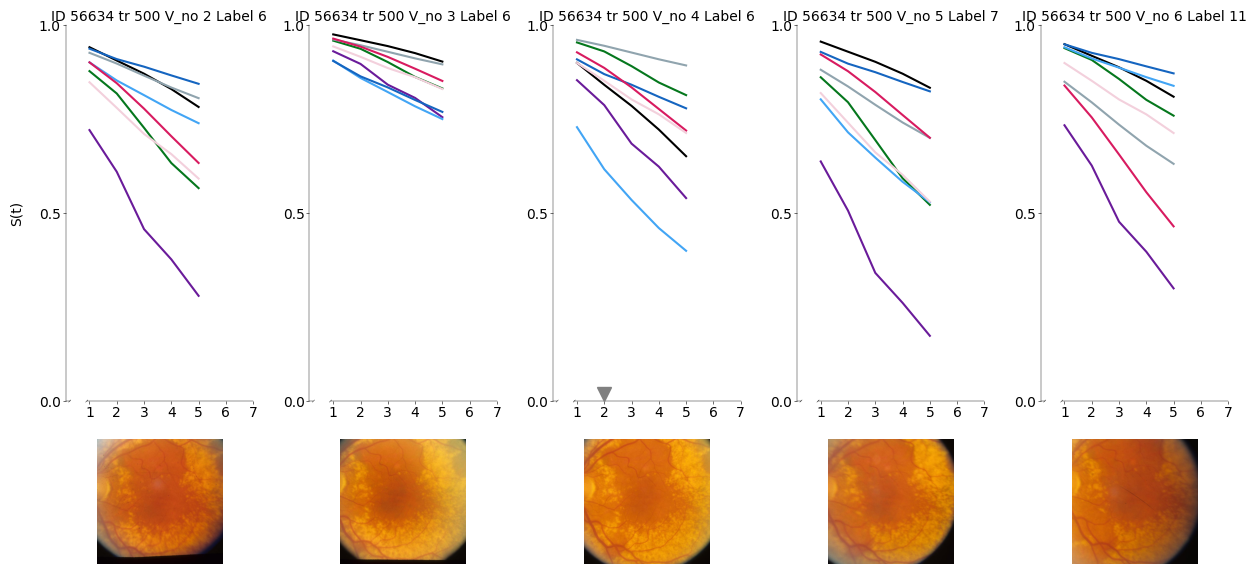

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_30000_mlp_2026-06-08_11...   
dino_nako     [testrun_False_FE_True_30000_mlp_2026-06-08_14...   
nako_mae      [testrun_False_FE_True_30000_mlp_2026-06-10_10...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

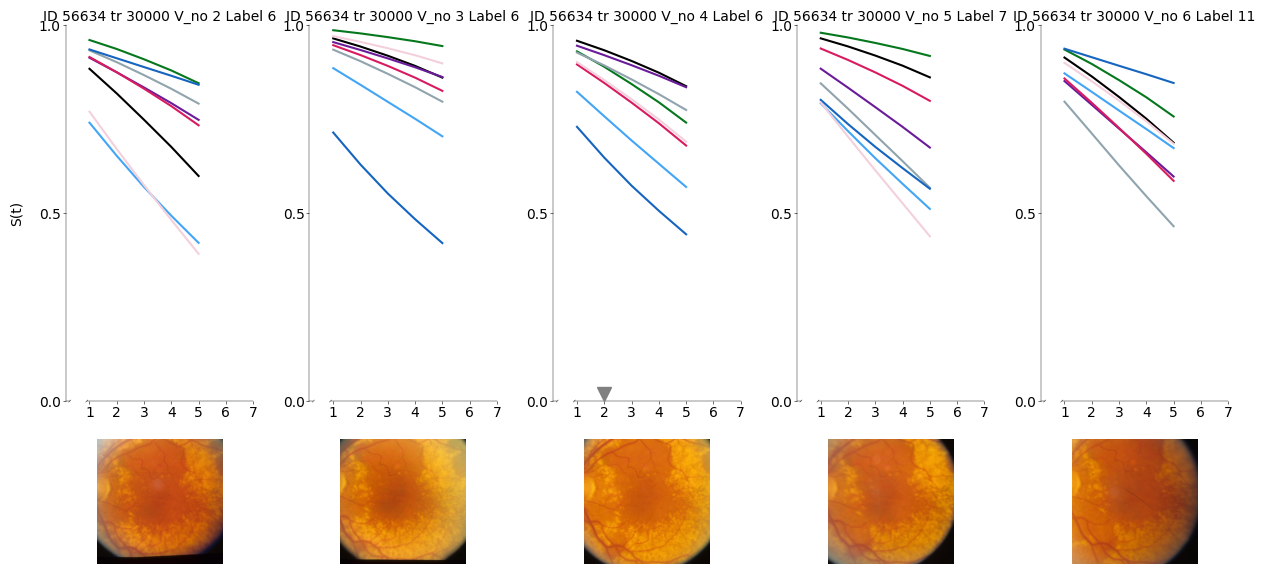

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_False_500_mlp_2026-06-07_16-...   
dino_nako     [testrun_False_FE_False_500_mlp_2026-06-05_04-...   
nako_mae      [testrun_False_FE_False_500_mlp_2026-06-05_02-...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

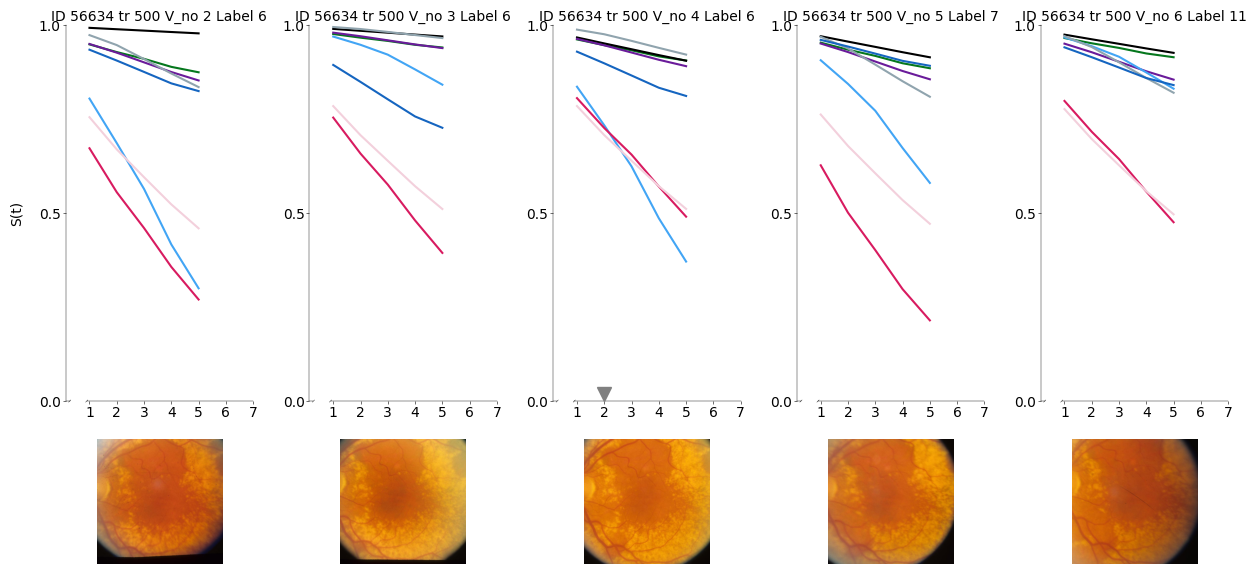

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_False_30000_mlp_2026-06-05_0...   
dino_nako     [testrun_False_FE_False_30000_mlp_2026-06-04_1...   
nako_mae      [testrun_False_FE_False_30000_mlp_2026-06-04_1...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

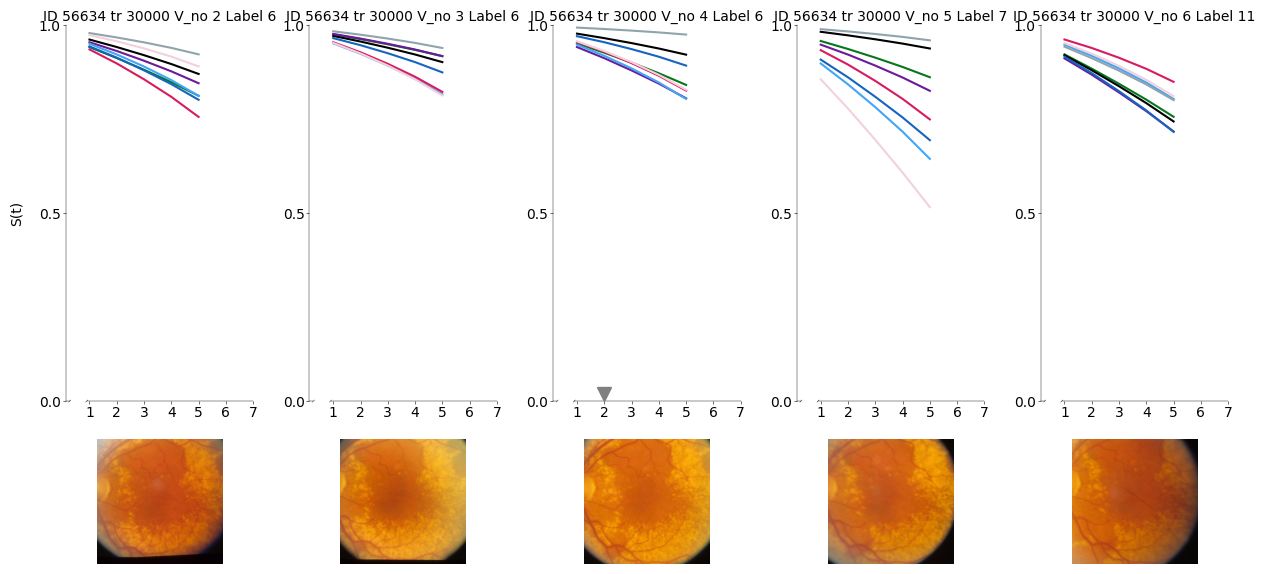

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

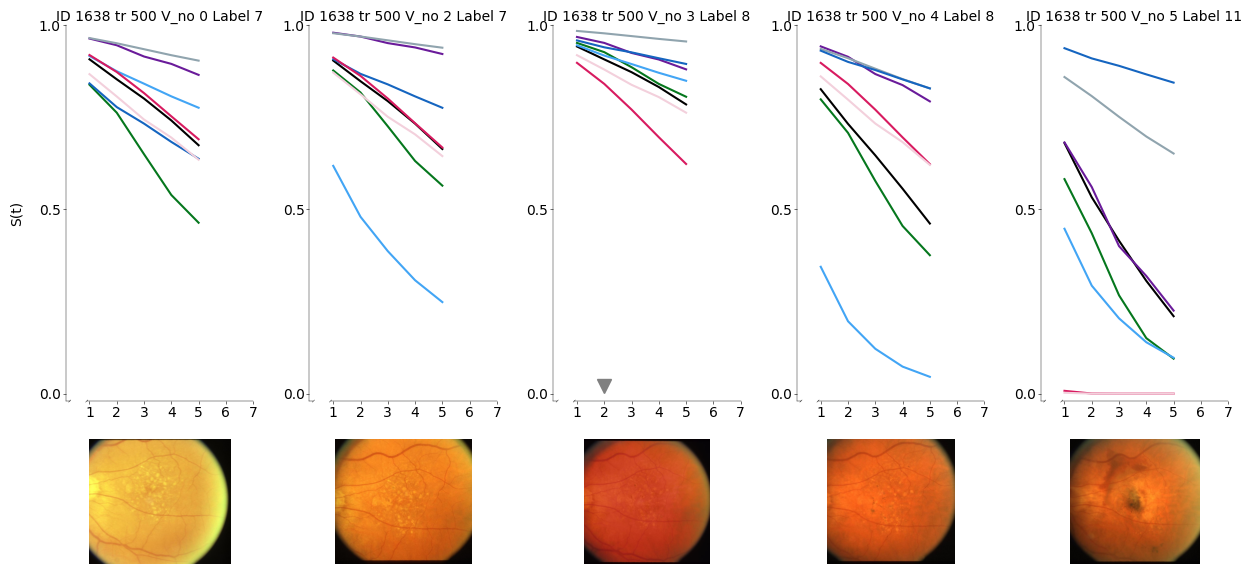

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_30000_mlp_2026-06-08_11...   
dino_nako     [testrun_False_FE_True_30000_mlp_2026-06-08_14...   
nako_mae      [testrun_False_FE_True_30000_mlp_2026-06-10_10...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

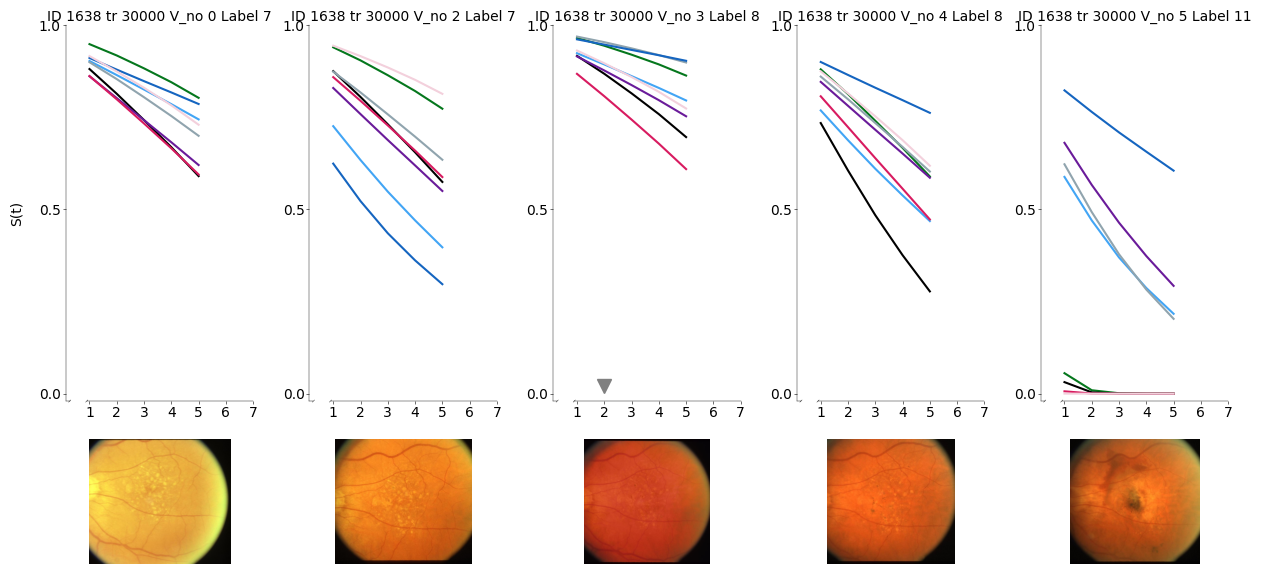

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_False_500_mlp_2026-06-07_16-...   
dino_nako     [testrun_False_FE_False_500_mlp_2026-06-05_04-...   
nako_mae      [testrun_False_FE_False_500_mlp_2026-06-05_02-...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

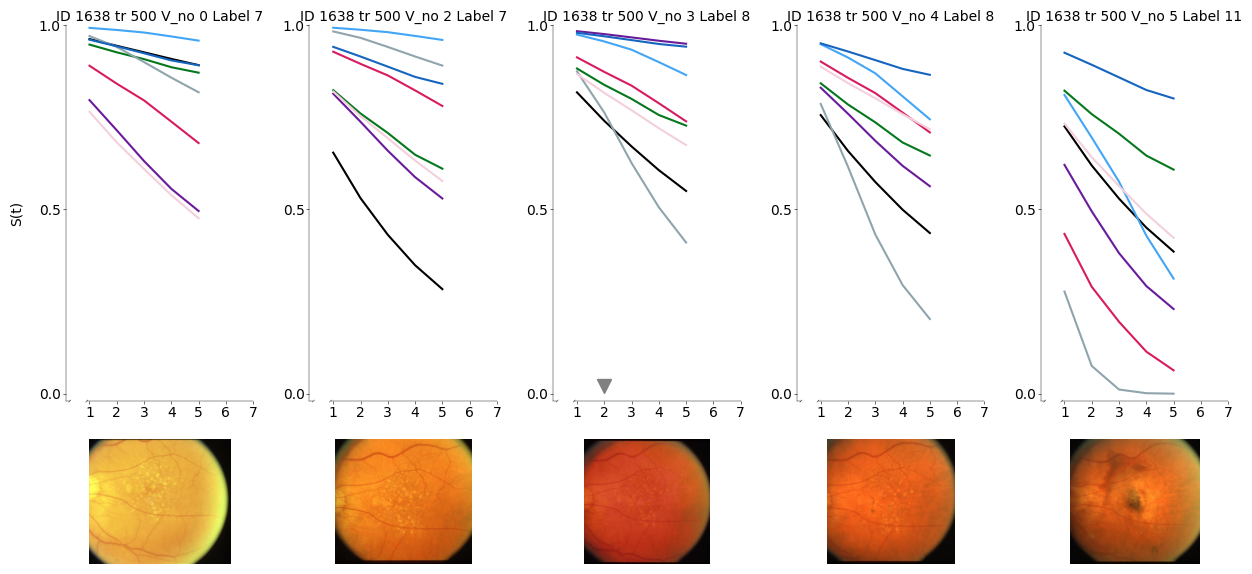

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_False_30000_mlp_2026-06-05_0...   
dino_nako     [testrun_False_FE_False_30000_mlp_2026-06-04_1...   
nako_mae      [testrun_False_FE_False_30000_mlp_2026-06-04_1...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

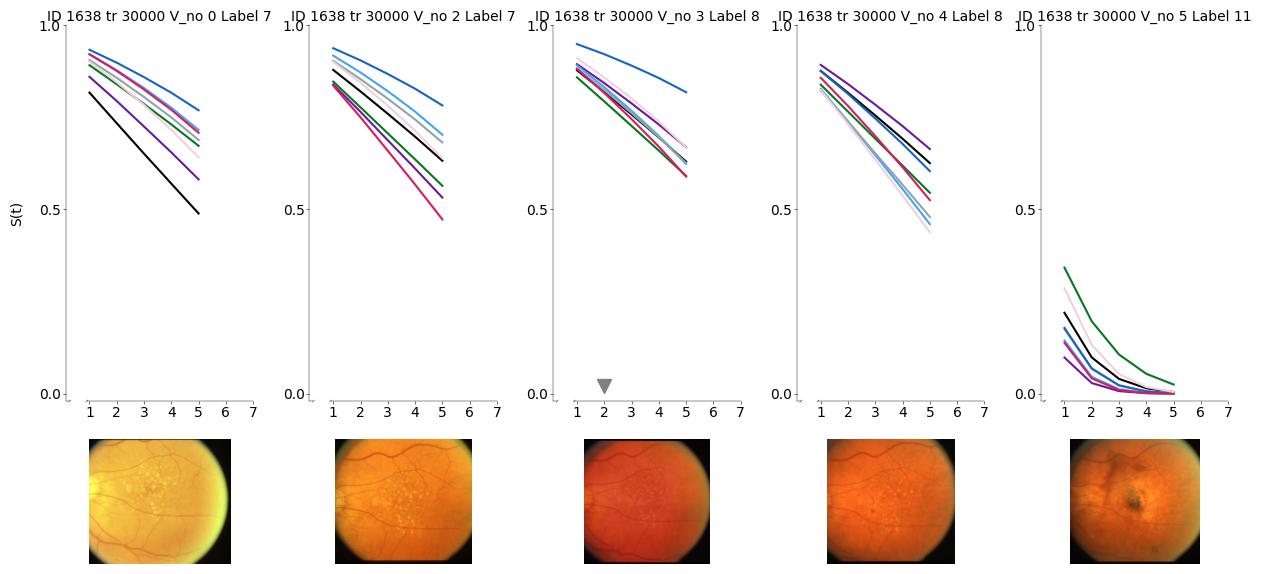

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

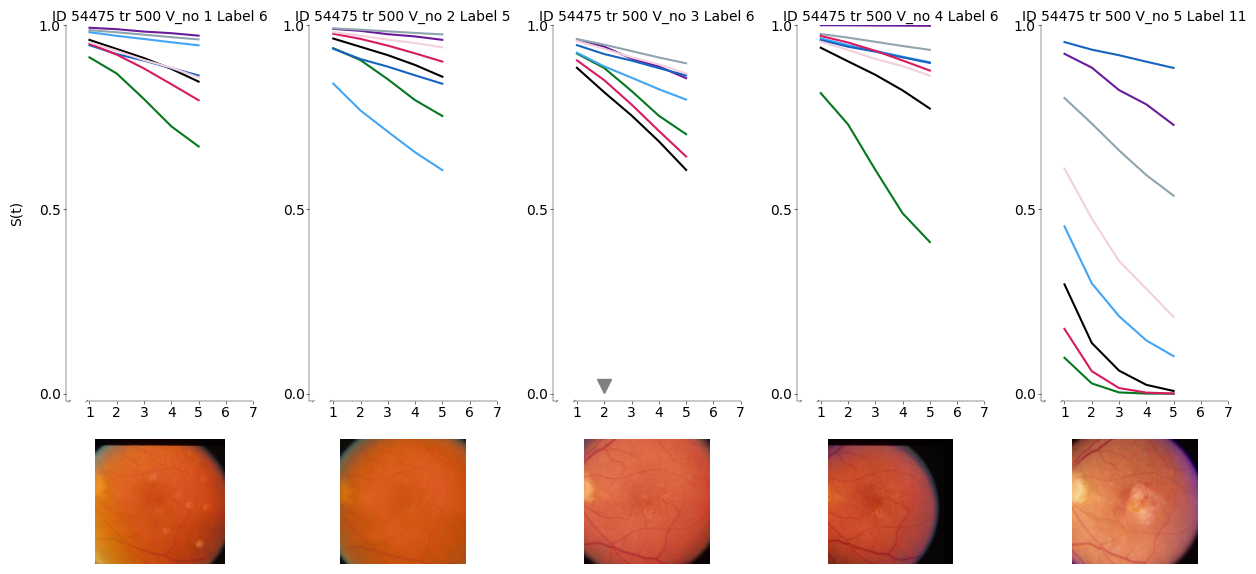

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_30000_mlp_2026-06-08_11...   
dino_nako     [testrun_False_FE_True_30000_mlp_2026-06-08_14...   
nako_mae      [testrun_False_FE_True_30000_mlp_2026-06-10_10...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

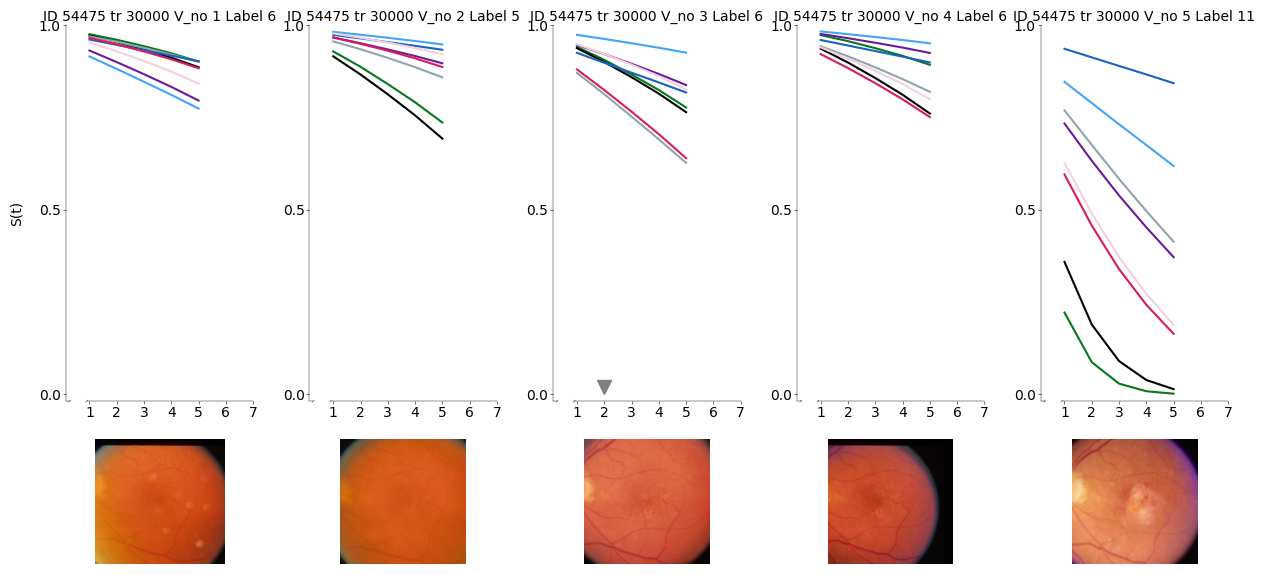

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_False_500_mlp_2026-06-07_16-...   
dino_nako     [testrun_False_FE_False_500_mlp_2026-06-05_04-...   
nako_mae      [testrun_False_FE_False_500_mlp_2026-06-05_02-...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

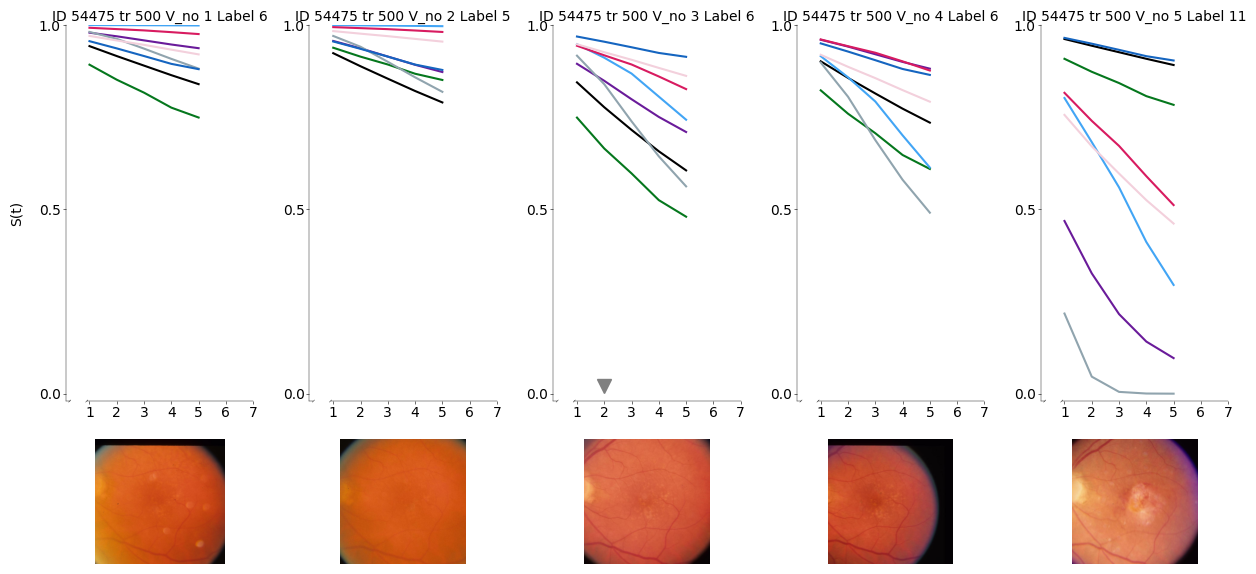

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_False_30000_mlp_2026-06-05_0...   
dino_nako     [testrun_False_FE_False_30000_mlp_2026-06-04_1...   
nako_mae      [testrun_False_FE_False_30000_mlp_2026-06-04_1...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

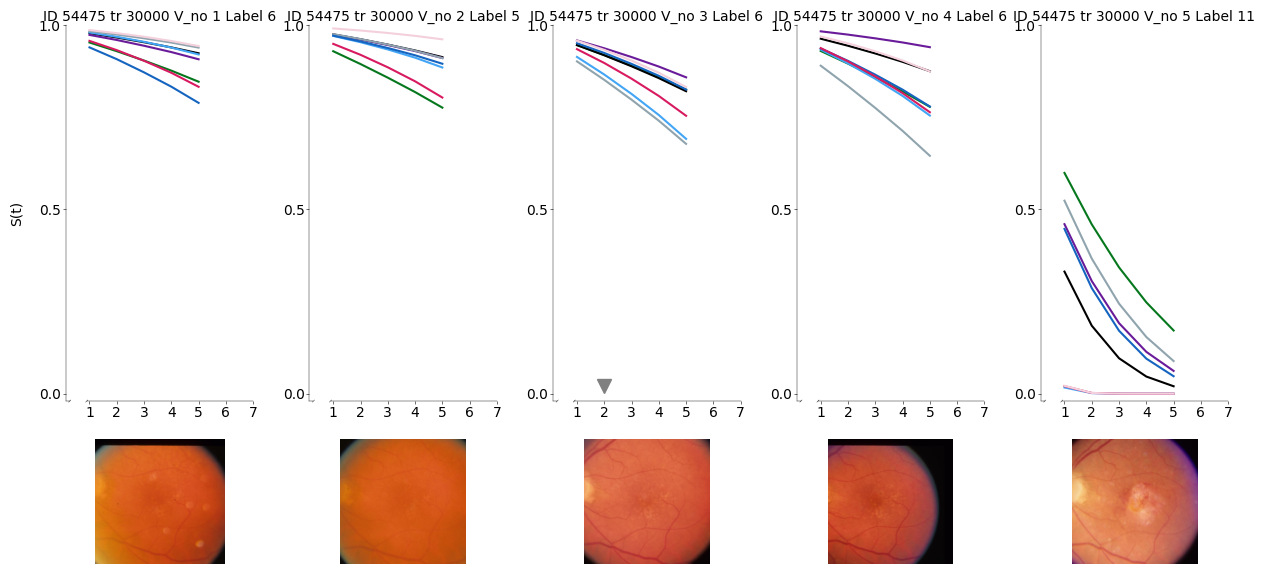

In [33]:
nested_data = {}

for pid_to_check in pds_to_check[0:3]:
    for i, vals in enumerate(info_dict):
        # vals = info_dict[0]
        freeze_encoder = vals['freeze_encoder']
        train_size = vals['train_size']
        has_event = vals['has_event']
        try:

            dict1, img_to_plot, train_size_returned = plot_one_image_curve(
                or_df, test, freeze_encoder=freeze_encoder,
                train_size=train_size, num_images=None, has_event=has_event,
                CHKPT_DIR=CHKPT_DIR, to_plot_row_index=0, patient_id = pid_to_check
            )

            assert train_size == train_size_returned, "different train values"
            patient_id = img_to_plot['patient_id']
            n_images = len(img_to_plot['image_path'])

            for idx, (img_path, diag, visit,  pid ) in enumerate(zip(
                img_to_plot['image_path'],
                img_to_plot['diagnosis_amd_grade'],
                img_to_plot['visit_number'],
                patient_id
            )):
                # Pull out this image's curve from each model
                model_curves = {model: curves[idx] for model, curves in dict1.items()}

                nested_data.setdefault(str(pid), {})[img_path] = {
                    'diagnosis_amd_grade': diag,
                    'visit_number': visit,
                    'model_curves': model_curves,
                    'train_size': train_size_returned
            }

            draw_curves_nested(nested_data, save_path=RESULTS_DIR, stylef=stylef)
            nested_data = {}
        except ValueError:
            print('error')
            no_pid.append(pid_to_check)

In [34]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
nested_data = {}
for i, vals in enumerate(info_dict):
    # vals = info_dict[0]
    freeze_encoder = vals['freeze_encoder']
    train_size = vals['train_size']
    has_event = vals['has_event']

    dict1, img_to_plot, train_size_returned = plot_one_image_curve(
        or_df, test, freeze_encoder=freeze_encoder,
        train_size=train_size, num_images=None, has_event=has_event,
        CHKPT_DIR=CHKPT_DIR, to_plot_row_index=0, patient_id = 3640
    )

    assert train_size == train_size_returned, "different train values"
    patient_id = img_to_plot['patient_id']
    n_images = len(img_to_plot['image_path'])

    for idx, (img_path, diag, visit,  pid ) in enumerate(zip(
        img_to_plot['image_path'],
        img_to_plot['diagnosis_amd_grade'],
        img_to_plot['visit_number'],
        patient_id
    )):
        # Pull out this image's curve from each model
        model_curves = {model: curves[idx] for model, curves in dict1.items()}

        nested_data.setdefault(str(pid), {})[img_path] = {
            'diagnosis_amd_grade': diag,
            'visit_number': visit,
            'model_curves': model_curves,
            'train_size': train_size_returned
    }

    draw_curves_nested(nested_data, save_path=RESULTS_DIR, stylef=stylef)


[8.0, 9.0, 8.0, 8.0, 11.0]
first conversion index is 4
marker x is 2 marker_panel_idx is 2


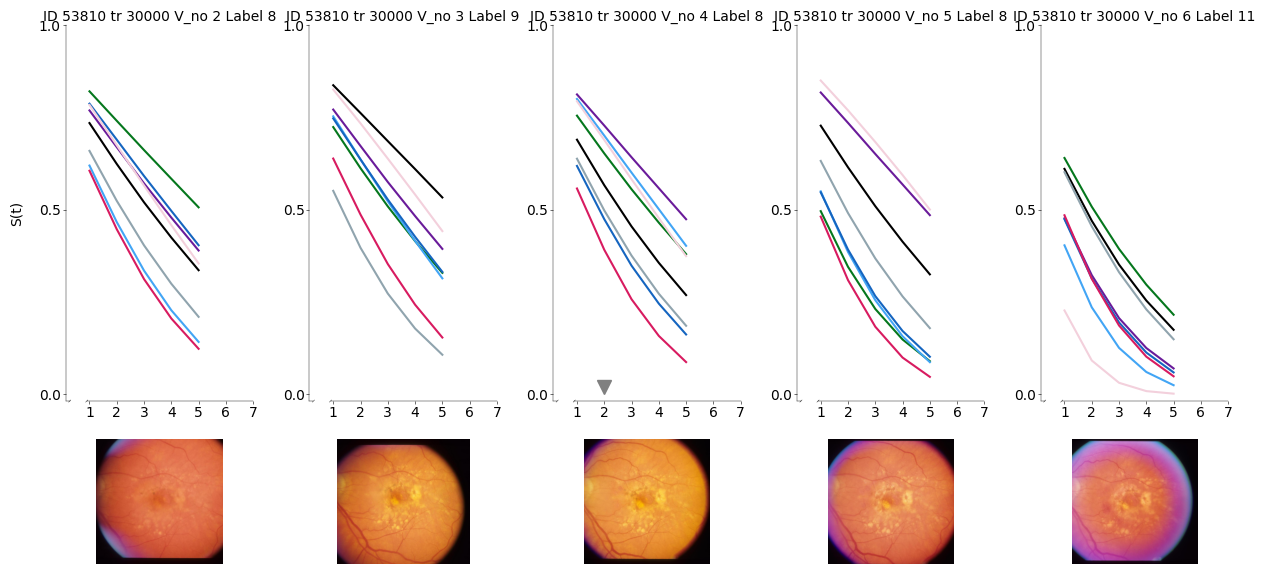

In [ ]:
draw_curves_nested(nested_data, save_path=RESULTS_DIR, stylef=stylef)

In [ ]:
# for x, y in nested_data.items():
#     print(x)
#     for h, i in y.items():
#         print(h)
#         print(i)
#         print()
#         print()
#         print('-------------------------------------')
#     print()
#     print()
#     print('**************************************')

## Consolidate

all_images_to_plot image_path             [55445/55445_02_F2_LE_RS.jpg, 55445/55445_04_F...

patient ID 2923, train size 30000

#done
{'image_path': ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg'], 'diagnosis_amd_grade': [5.0, 5.0, 7.0, 8.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [30000, 30000, 30000, 30000, 30000]}

{'image_path': ['53810/53810_04_F2_LE_LS.jpg', '53810/53810_06_F2_LE_LS.jpg', '53810/53810_08_F2_LE_LS.jpg', '53810/53810_10_F2_LE_LS.jpg', '53810/53810_12_F2_LE_RS.jpg'], 'diagnosis_amd_grade': [8.0, 9.0, 8.0, 8.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['53810/53810_04_F2_LE_LS.jpg', '53810/53810_06_F2_LE_LS.jpg', '53810/53810_08_F2_LE_LS.jpg', '53810/53810_10_F2_LE_LS.jpg', '53810/53810_12_F2_LE_RS.jpg']
image_paths[0] 53810/53810_04_F2_LE_LS.jpg
all_img_to_plot ['53810/53810_04_F2_LE_LS.jpg', '53810/53810_06_F2_LE_LS.jpg', '53810/53810_08_F2_LE_LS.jpg', '53810/53810_10_F2_LE_LS.jpg', '53810/53810_12_F2_LE_RS.jpg']
[8.0, 9.0, 8.0, 8.0, 11.0]
marker x is 5 marker_panel_idx is 3

#done
{'image_path': ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg'], 'diagnosis_amd_grade': [5.0, 5.0, 7.0, 8.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [500, 500, 500, 500, 500]}
image_paths ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg']
image_paths[0] 53622/53622_04_F2_RE_LS.jpg
all_img_to_plot ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg']
[5.0, 5.0, 7.0, 8.0, 11.0]
marker x is 5 marker_panel_idx is 3


{'image_path': ['3935/3935_00_RE_F2_LS.jpg', '53331/53331_02_F2_RE_LS.jpg', '3935/3935_04_RE_F2_LS.jpg', '53331/53331_06_F2_RE_LS.jpg', '3935/3935_08_RE_F2_RS.jpg'], 'diagnosis_amd_grade': [7.0, 7.0, 8.0, 9.0, 10.0], 'visit_number': [0, 2, 4, 6, 8], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['3935/3935_00_RE_F2_LS.jpg', '53331/53331_02_F2_RE_LS.jpg', '3935/3935_04_RE_F2_LS.jpg', '53331/53331_06_F2_RE_LS.jpg', '3935/3935_08_RE_F2_RS.jpg']
image_paths[0] 3935/3935_00_RE_F2_LS.jpg
all_img_to_plot ['3935/3935_00_RE_F2_LS.jpg', '53331/53331_02_F2_RE_LS.jpg', '3935/3935_04_RE_F2_LS.jpg', '53331/53331_06_F2_RE_LS.jpg', '3935/3935_08_RE_F2_RS.jpg']
[7.0, 7.0, 8.0, 9.0, 10.0]
marker x is 5 marker_panel_idx is 3

{'image_path': ['3290/3290_04_LE_F2_RS.jpg', '3290/3290_08_LE_F2_LS.jpg', '61507/61507_10_F2_LE_RS.jpg', '3290/3290_12_LE_F2_RS.jpg', '3290/3290_16_LE_F2_LS.jpg'], 'diagnosis_amd_grade': [9.0, 9.0, 9.0, 3.0, 10.0], 'visit_number': [4, 8, 10, 12, 16], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['3290/3290_04_LE_F2_RS.jpg', '3290/3290_08_LE_F2_LS.jpg', '61507/61507_10_F2_LE_RS.jpg', '3290/3290_12_LE_F2_RS.jpg', '3290/3290_16_LE_F2_LS.jpg']
image_paths[0] 3290/3290_04_LE_F2_RS.jpg
all_img_to_plot ['3290/3290_04_LE_F2_RS.jpg', '3290/3290_08_LE_F2_LS.jpg', '61507/61507_10_F2_LE_RS.jpg', '3290/3290_12_LE_F2_RS.jpg', '3290/3290_16_LE_F2_LS.jpg']
[9.0, 9.0, 9.0, 3.0, 10.0]
marker x is 5 marker_panel_idx is 3

{'image_path': ['58462/58462_04_F2_RE_RS.jpg', '58462/58462_06_F2_RE_LS.jpg', '58462/58462_08_F2_RE_LS.jpg', '58462/58462_10_F2_RE_RS.jpg', '58462/58462_12_F2_RE_LS.jpg'], 'diagnosis_amd_grade': [6.0, 6.0, 6.0, 6.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['58462/58462_04_F2_RE_RS.jpg', '58462/58462_06_F2_RE_LS.jpg', '58462/58462_08_F2_RE_LS.jpg', '58462/58462_10_F2_RE_RS.jpg', '58462/58462_12_F2_RE_LS.jpg']
image_paths[0] 58462/58462_04_F2_RE_RS.jpg
all_img_to_plot ['58462/58462_04_F2_RE_RS.jpg', '58462/58462_06_F2_RE_LS.jpg', '58462/58462_08_F2_RE_LS.jpg', '58462/58462_10_F2_RE_RS.jpg', '58462/58462_12_F2_RE_LS.jpg']
[6.0, 6.0, 6.0, 6.0, 11.0]
marker x is 5 marker_panel_idx is 3

In [ ]:
test[test['image_path']=='53810/53810_04_F2_LE_LS.jpg']

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event,converter
2834,2346,2346_left,2346_left_LS_04,4,left,F2,LS,53810_04_F2_LE_LS.jpg,53810/53810_04_F2_LE_LS.jpg,8.0,...,N,N,11.0,Y,80.1,2346_left,2346_left_4,8,1,False


['4192',
 '3162',
 'G112',
 'G498',
 '1142',
 'G547',
 '5358',
 'G193',
 '4769',
 '2905',
 '3133',
 '5050',
 '1984',
 '3640',
 '3368',
 '3968',
 '2795',
 '2224',
 '1818',
 '3827',
 '4472',
 '1925',
 '3101',
 '2304',
 '3167',
 '5541',
 '5658',
 '2737',
 '5700',
 '3054',
 '2963',
 '2662',
 '3531',
 '4079',
 '4946',
 'G538',
 'G570',
 '2938',
 '2191',
 '1011',
 '3935',
 '4143',
 '5578',
 'G119',
 '3696',
 '3201',
 '2356',
 '3532',
 '1501',
 '2222',
 '5524',
 '1802',
 '3854',
 '5119',
 '2002',
 '3538',
 '3609',
 '5633',
 '3933',
 'G035',
 '3000',
 '4059',
 '1039',
 '5432',
 'G535',
 '4420',
 '5684',
 '2022',
 '2320',
 '4558',
 '4994',
 '5602',
 'G126',
 '4747',
 'G557',
 '4570',
 '2163',
 '2878',
 '4061',
 '4323',
 '5055',
 '5075',
 '4279',
 '1882',
 '5127',
 '2600',
 'G054',
 '2238',
 '1683',
 '2521',
 '3606',
 '3890',
 '1051',
 'G034',
 '2672',
 '1996',
 'G554',
 '3178',
 '3978',
 'G457',
 '3102',
 '1234',
 '3346',
 'G229',
 'G143',
 '1046',
 '5646',
 '3307',
 '1052',
 '2074',
 '2085',
 